# Merge and Export Machine Learning Dataset - Berlin
This notebook gathers all pre-calculated features (OSM POIs, Land Use, Terrain/Momepy) and merges them into one comprehensive `.csv` table for the Berlin ML models.

## Note: Data Requirements

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

print("Libraries imported.")

Libraries imported.


## Load the datasets

In [2]:
path_osm_roads    = "data/osm_roads_noise_class.csv"
path_momepy_roads = "data/momepy_roads_features.csv"
path_osm_points   = "data/osm_points_features.csv"
path_osmlanduse   = "data/osm_landuse_features.csv"

df_osm_roads    = pd.read_csv(path_osm_roads)
df_momepy_roads = pd.read_csv(path_momepy_roads)
df_osm_points   = pd.read_csv(path_osm_points)
df_osm_landuse  = pd.read_csv(path_osmlanduse)

print("Data loaded successfully.")

Data loaded successfully.


In [3]:
df_osm_roads.head()

,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,172539_172562_0,2,2,1,3,19406.495889,0.000000,0.0,0.0,130.367348,845.336539
1,172539_34694336_0,2,2,1,3,19015.019606,435.703514,0.0,0.0,0.000000,867.701362
2,172539_34694265_0,2,2,1,4,19175.649431,431.894550,0.0,0.0,0.000000,867.701362
3,172545_271370539_0,3,3,2,4,18944.230854,800.614365,0.0,0.0,101.228333,996.552367
4,172545_34694336_0,2,2,1,3,18957.026756,800.614365,0.0,0.0,0.000000,996.552367


In [4]:
# Drop non-ML columns from momepy (openness and height are morphological intermediates)
df_momepy_roads.drop(['openness', 'height'], axis=1, inplace=True)
df_momepy_roads.head()

,road_id,width,betw_centrality,clos_centrality,straightness,closeness400
0,172539_172562_0,28.940821,177.0,0.000005,0.904821,2.819245e-06
1,172562_172539_0,28.942026,177.0,0.000005,0.904821,2.819245e-06
2,172539_34694336_0,43.648847,13.5,0.000003,0.933794,6.748056e-07
3,34694336_172539_0,43.648664,13.5,0.000003,0.933794,6.748056e-07
4,172539_34694265_0,37.132640,22.5,0.000002,0.886788,7.868624e-07


In [5]:
df_osm_points.head()

,road_id,signals,transport,pois
0,172539_172562_0,0.027463,0.009154,0.002289
1,172539_34694336_0,0.007274,0.002910,0.000000
2,172539_34694265_0,0.020748,0.008299,0.000000
3,172545_271370539_0,0.050295,0.026704,0.000000
4,172545_34694336_0,0.050295,0.019385,0.000000


In [6]:
df_osm_landuse.head()

,road_id,green,industrial,commercial
0,172539_172562_0,46.818402,0.0,15.475264
1,172539_34694336_0,50.593614,0.0,1.881108
2,172539_34694265_0,14.723614,0.0,12.769612
3,172545_271370539_0,19.276736,0.0,6.213337
4,172545_34694336_0,8.047110,0.0,11.937565


## Merge dataframes

In [7]:
def merge_feature_dataframe(base_df, feature_df, cols_to_drop):
    clean_df = feature_df.drop(columns=[c for c in cols_to_drop if c in feature_df.columns], errors='ignore')
    cols_to_remove = [c for c in clean_df.columns if c in base_df.columns and c != 'road_id']
    clean_df = clean_df.drop(columns=cols_to_remove, errors='ignore')
    if 'road_id' not in clean_df.columns or 'road_id' not in base_df.columns:
        return base_df
    clean_df['road_id'] = clean_df['road_id'].astype(str)
    base_df = base_df.copy()
    base_df['road_id'] = base_df['road_id'].astype(str)
    return base_df.merge(clean_df, on='road_id', how='left')

In [8]:
ml_dataset = df_osm_roads.copy()
cols_to_drop = ['noise_day', 'noise_evening', 'noise_night']

print("Road ID types:")
print(f"ml_dataset: {ml_dataset['road_id'].dtype}")

for name, df in [
    ('OSM Points',   df_osm_points),
    ('Momepy Roads', df_momepy_roads),
    ('OSM Landuse',  df_osm_landuse),
]:
    if 'road_id' in df.columns:
        print(f"{name}: {df['road_id'].dtype}")
    else:
        print(f"{name}: NO road_id column!")
    ml_dataset = merge_feature_dataframe(ml_dataset, df, cols_to_drop)

ml_dataset = ml_dataset.fillna(0)

display(ml_dataset.head(10))
ml_dataset.info()
print(f"Final dataset shape: {ml_dataset.shape}")

Road ID types:
ml_dataset: str
OSM Points: str
Momepy Roads: str
OSM Landuse: str


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,...,transport,pois,width,betw_centrality,clos_centrality,straightness,closeness400,green,industrial,commercial
0,172539_172562_0,2,2,1,3,19406.495889,0.000000,0.000000,0.000000,130.367348,...,0.009154,0.002289,28.940821,177.0,0.000005,0.904821,2.819245e-06,46.818402,0.0,15.475264
1,172539_34694336_0,2,2,1,3,19015.019606,435.703514,0.000000,0.000000,0.000000,...,0.002910,0.000000,43.648847,13.5,0.000003,0.933794,6.748056e-07,50.593614,0.0,1.881108
2,172539_34694265_0,2,2,1,4,19175.649431,431.894550,0.000000,0.000000,0.000000,...,0.008299,0.000000,37.132640,22.5,0.000002,0.886788,7.868624e-07,14.723614,0.0,12.769612
3,172545_271370539_0,3,3,2,4,18944.230854,800.614365,0.000000,0.000000,101.228333,...,0.026704,0.000000,50.000000,38.5,0.000003,0.919533,1.828302e-06,19.276736,0.0,6.213337
4,172545_34694336_0,2,2,1,3,18957.026756,800.614365,0.000000,0.000000,0.000000,...,0.019385,0.000000,49.244843,36.5,0.000003,0.937117,1.431952e-06,8.047110,0.0,11.937565
5,172545_28345515_0,2,2,1,4,18957.026756,631.324162,0.000000,0.000000,0.000000,...,0.023285,0.005821,42.807543,65.5,0.000003,0.832278,1.429051e-06,4.821879,0.0,0.868854
6,172546_28345850_0,3,3,2,3,18724.937644,654.325566,0.000000,314.318263,44.752758,...,0.026704,0.019155,34.813549,123.0,0.000005,0.875415,3.896279e-06,7.309701,0.0,0.000000
7,172546_530313_0,3,3,2,3,18707.192874,609.420663,0.000000,364.880692,0.000000,...,0.022137,0.000000,29.568842,109.5,0.000005,0.869128,3.542744e-06,1.660445,0.0,9.801486
8,172547_28346151_0,1,1,0,5,19076.030136,433.299111,245.062216,0.000000,0.000000,...,0.009248,0.000000,37.841945,43.0,0.000002,0.771413,9.999323e-07,14.958962,0.0,0.000000
9,172547_172549_0,2,2,1,4,18888.999084,531.979259,245.062216,0.000000,0.000000,...,0.012553,0.000000,37.714311,41.0,0.000002,0.792129,1.128043e-06,1.158002,0.0,2.241359


<class 'pandas.DataFrame'>
RangeIndex: 70890 entries, 0 to 70889
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   road_id                70890 non-null  str    
 1   noise_day              70890 non-null  int64  
 2   noise_evening          70890 non-null  int64  
 3   noise_night            70890 non-null  int64  
 4   road_category          70890 non-null  int64  
 5   dist_to_trunk          70890 non-null  float64
 6   dist_to_primary        70890 non-null  float64
 7   dist_to_secondary      70890 non-null  float64
 8   dist_to_tertiary       70890 non-null  float64
 9   dist_to_residential    70890 non-null  float64
 10  dist_to_living_street  70890 non-null  float64
 11  signals                70890 non-null  float64
 12  transport              70890 non-null  float64
 13  pois                   70890 non-null  float64
 14  width                  70890 non-null  float64
 15  betw_centrali

## Noise distribution

     Day  Evening  Night
0   2406     2406  25038
1  31566    31566  27808
2  22730    22730  13916
3  11993    11993   3994
4   2195     2195    134


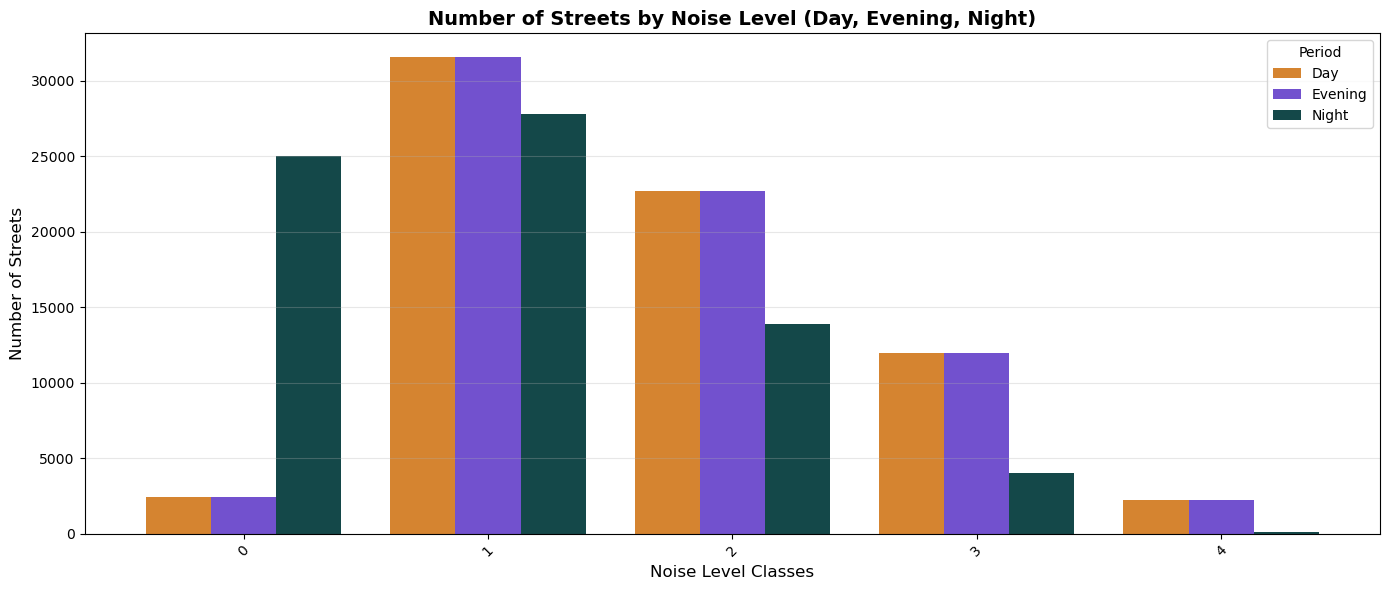

In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

counts_day     = ml_dataset.groupby('noise_day').size()
counts_evening = ml_dataset.groupby('noise_evening').size()
counts_night   = ml_dataset.groupby('noise_night').size()

comparison_df = pd.DataFrame({'Day': counts_day, 'Evening': counts_evening, 'Night': counts_night})

print(comparison_df)
comparison_df[['Day', 'Evening', 'Night']].plot(
    kind='bar', ax=ax, width=0.8, color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Number of Streets by Noise Level (Day, Evening, Night)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level Classes', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export to CSV
Final master table for scikit-learn in the next phase.

In [10]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "ber_noise_class_ml_dataset.csv")
ml_dataset.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\ber_noise_class_ml_dataset.csv


## Subsample
Stratified subsample of 5000 segments preserving noise_day class distribution.

In [11]:
sample_size = 5000

proportions = ml_dataset['noise_day'].value_counts(normalize=True).sort_index()
samples_per_value = (proportions * sample_size).round().astype(int)

subsampled = pd.concat([
    ml_dataset[ml_dataset['noise_day'] == val].sample(n=n, random_state=42, replace=False)
    for val, n in samples_per_value.items() if n > 0
])

subsampled = subsampled.sample(frac=1, random_state=42).reset_index(drop=True)

print(subsampled['noise_day'].value_counts(normalize=True).sort_index())

noise_day
0    0.0340
1    0.4452
2    0.3206
3    0.1692
4    0.0310
Name: proportion, dtype: float64


## Before and after sampling

           Before  After
noise_day               
0            2406    170
1           31566   2226
2           22730   1603
3           11993    846
4            2195    155


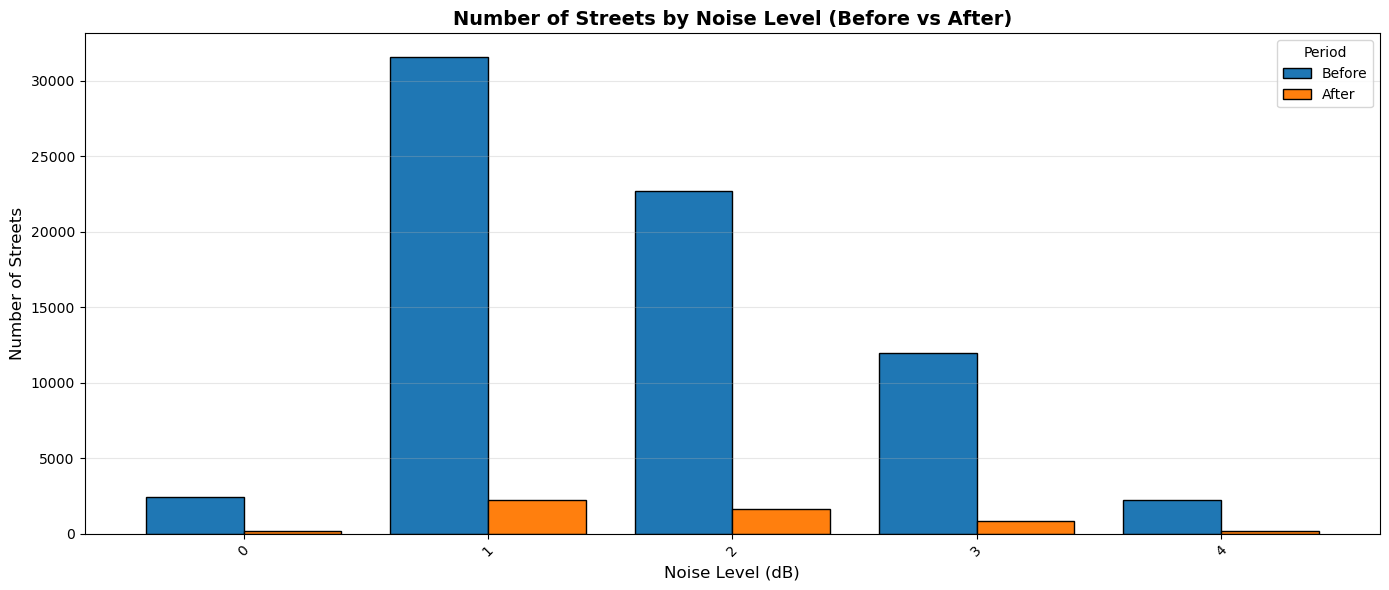

In [12]:
fig, ax = plt.subplots(figsize=(14, 6))

counts_before = ml_dataset.groupby('noise_day').size()
counts_after  = subsampled.groupby('noise_day').size()

comparison_df = pd.DataFrame({'Before': counts_before, 'After': counts_after})

print(comparison_df)
comparison_df[['Before', 'After']].plot(kind='bar', ax=ax, edgecolor='black', width=0.8)
ax.set_title('Number of Streets by Noise Level (Before vs After)', fontsize=14, fontweight='bold')
ax.set_xlabel('Noise Level (dB)', fontsize=12)
ax.set_ylabel('Number of Streets', fontsize=12)
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Period')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Export CSV

In [13]:
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)

final_path = os.path.join(output_dir, "ber_noise_class_ml_subsample.csv")
subsampled.to_csv(final_path, index=False)

print(f"Dataset successfully exported to: {final_path}")

Dataset successfully exported to: data\ber_noise_class_ml_subsample.csv
